In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
fake_df=pd.read_csv(r"C:\Users\druth\OneDrive\Desktop\Projects\fake news detection\Fake.csv")

In [3]:
true_df=pd.read_csv(r"C:\Users\druth\OneDrive\Desktop\Projects\fake news detection\true.csv")

In [4]:
fake_df['label']=0
true_df['label']=1

In [5]:

true_df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [6]:
df=pd.concat([true_df,fake_df])
df=df.sample(frac=1).reset_index(drop=True)

In [7]:
df.head(10)

,title,text,subject,date,label
0,Pence's mission in Europe: clarify Trump's for...,WASHINGTON/BERLIN (Reuters) - U.S. Vice Presid...,politicsNews,"February 15, 2017",1
1,"Trump pushes drugmakers for lower prices, more...",WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"January 31, 2017",1
2,SIZE OF CROWDS TRUMP Is Drawing VS HILLARY Pro...,"Earlier this week, it was rumored that Hillary...",left-news,"Aug 3, 2016",0
3,"Pope, at service for Africa, decries murder of...",VATICAN CITY (Reuters) - Pope Francis on Thurs...,worldnews,"November 23, 2017",1
4,"With Obamacare vote, House Republicans free to...",WASHINGTON (Reuters) - The Republican-controll...,politicsNews,"May 5, 2017",1
5,Turkish court orders detention of two over U.S...,ISTANBUL (Reuters) - A Turkish court has issue...,worldnews,"November 28, 2017",1
6,New Zealand PM-designate confirms review of ce...,SYDNEY (Reuters) - New Zealand prime minister-...,worldnews,"October 24, 2017",1
7,Russian election hacking 'wildly successful' i...,"CAMBRIDGE, Mass. (Reuters) - Russia succeeded ...",politicsNews,"May 2, 2017",1
8,Opposition wants Russian pressure for Syria de...,GENEVA (Reuters) - Syria s opposition wants Ru...,worldnews,"November 29, 2017",1
9,DID IRAN RELEASE This Footage Of Captured U.S....,And what about the female sailor in the headsc...,Government News,"Jan 14, 2016",0


In [8]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [17]:
df["content"] = (df["title"].astype(str) + " " + df["text"].astype(str)).fillna("")

C:\Users\druth\AppData\Local\Temp\ipykernel_3576\1833769429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data=df, palette='Set2')


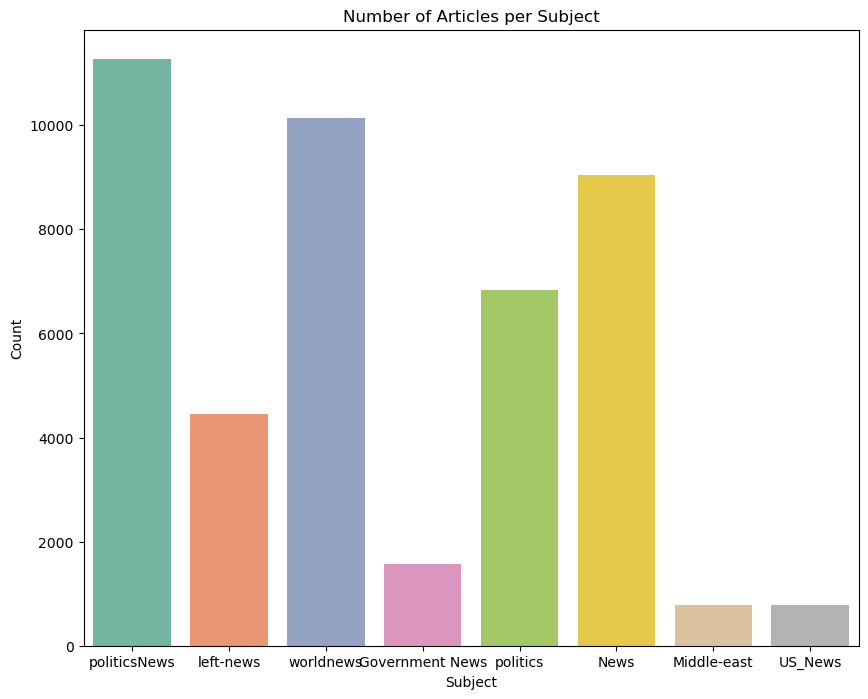

In [23]:
import seaborn as sns 
plt.figure(figsize=(10, 8))
sns.countplot(x='subject', data=df, palette='Set2')
plt.title("Number of Articles per Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

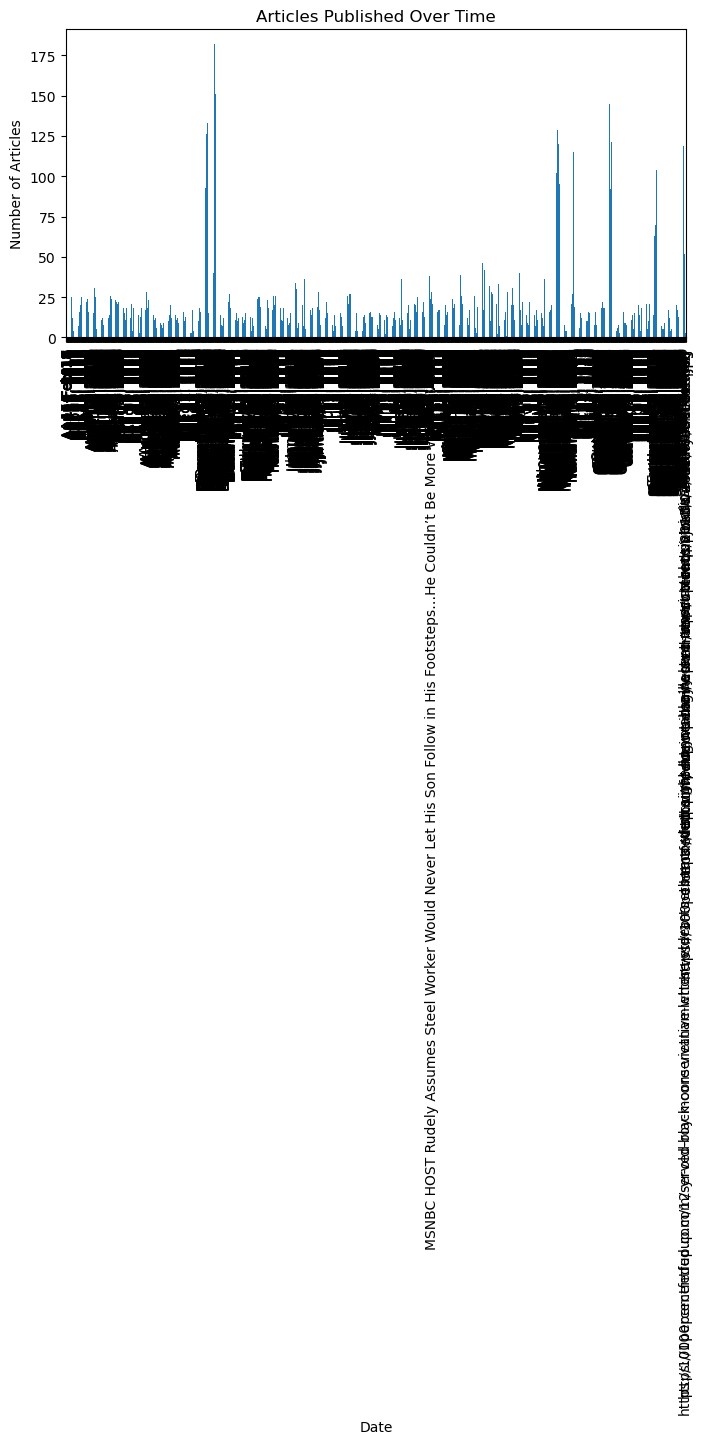

In [25]:
plt.figure(figsize=(8, 4))
df['date'].value_counts().sort_index().plot(kind='bar')
plt.title("Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

In [21]:
X= df['content'].astype(str)
Y= df['label']

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [25]:
vectorizer=TfidfVectorizer(stop_words="english",max_df=0.7)
X_train_tfdi=vectorizer.fit_transform(X_train)
X_test_tfdi=vectorizer.transform(X_test)

In [27]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_bal,Y_train_bal= smote.fit_resample(X_train_tfdi,Y_train)

In [54]:
print(Y_train.value_counts())
print(Y_test.value_counts())
print(Y_train_bal.value_counts())

label
0    18791
1    17127
Name: count, dtype: int64
label
0    4690
1    4290
Name: count, dtype: int64
label
1    18791
0    18791
Name: count, dtype: int64


In [31]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_bal,Y_train_bal)
log_pred=log_model.predict(X_test_tfdi)

In [33]:
nb_model=MultinomialNB()
nb_model.fit(X_train_bal,Y_train_bal)
nb_pred=nb_model.predict(X_test_tfdi)

In [37]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_bal,Y_train_bal)
rf_pred=rf_model.predict(X_test_tfdi)

In [36]:
print("Logistic Regression model accuracy:",accuracy_score(Y_test,log_pred))
print("naive bayes model accuracy:",accuracy_score(Y_test,nb_pred))
print("Random Forest Model accuracy:",accuracy_score(Y_test,rf_pred))

Logistic Regression model accuracy: 0.9857461024498887
naive bayes model accuracy: 0.9367483296213809
Random Forest Model accuracy: 0.9896436525612472


In [40]:
models={"Logistic Regression":(log_model,log_pred),
       "Naive Bayes":(nb_model,nb_pred),
       "RandomForestClassifier":(rf_model,rf_pred)}

for name, (model,pred) in models.items():
    print(f"\n{name} reuslts:")
    print("Accuracy:",accuracy_score(Y_test,pred))
    print("\nClassification Report:\n",classification_report(Y_test,pred))
    print("\nConfusion Metrics\n",confusion_matrix(Y_test,pred))
    print("        ***********            ")


Logistic Regression reuslts:
Accuracy: 0.9857461024498887

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4690
           1       0.98      0.99      0.99      4290

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Metrics
 [[4609   81]
 [  47 4243]]
        ***********            

Naive Bayes reuslts:
Accuracy: 0.9367483296213809

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      4690
           1       0.93      0.94      0.93      4290

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


Confusion Metrics
 [[4371  319]
 [ 249 4041]]
        ***********            

RandomForestClassifier reus

In [50]:
sample_news = [
    "Breaking: Government announces new policy to improve healthcare system",
    "Scientists claim drinking coffee will make you live forever",
    "Donald Trump caught meeting aliens in secret base, sources say"
]

sample_tfdi=vectorizer.transform(sample_news)
prediction=nb_model.predict(sample_tfdi)
print("the sample news is:",prediction)

the sample news is: [1 0 0]


In [52]:
sample_news = [
    """The Prime Minister today unveiled a new healthcare reform bill in parliament.
    The bill aims to reduce costs and improve hospital facilities across the country.""",

    """A Facebook post went viral claiming that scientists discovered a pill that makes people live forever.
    Experts have dismissed the claim as baseless and misleading.""",

    """US President met with NATO leaders to discuss new defense strategies. 
    Officials confirmed that the talks focused on strengthening alliances and trade agreements."""
]

sample_tfidf = vectorizer.transform(sample_news)
predictions = nb_model.predict(sample_tfidf)

for news, pred in zip(sample_news, predictions):
    print("Prediction:", "Real" if pred==1 else "Fake")

Prediction: Real
Prediction: Fake
Prediction: Real
